FIRST 5 ROWS
   Are you self-employed?  \
0                       0   
1                       0   
2                       0   
3                       1   
4                       0   

  How many employees does your company or organization have?  \
0                                             26-100           
1                                               6-25           
2                                               6-25           
3                                                NaN           
4                                               6-25           

   Is your employer primarily a tech company/organization?  \
0                                                1.0         
1                                                1.0         
2                                                1.0         
3                                                NaN         
4                                                0.0         

   Is your primary role within your company related to

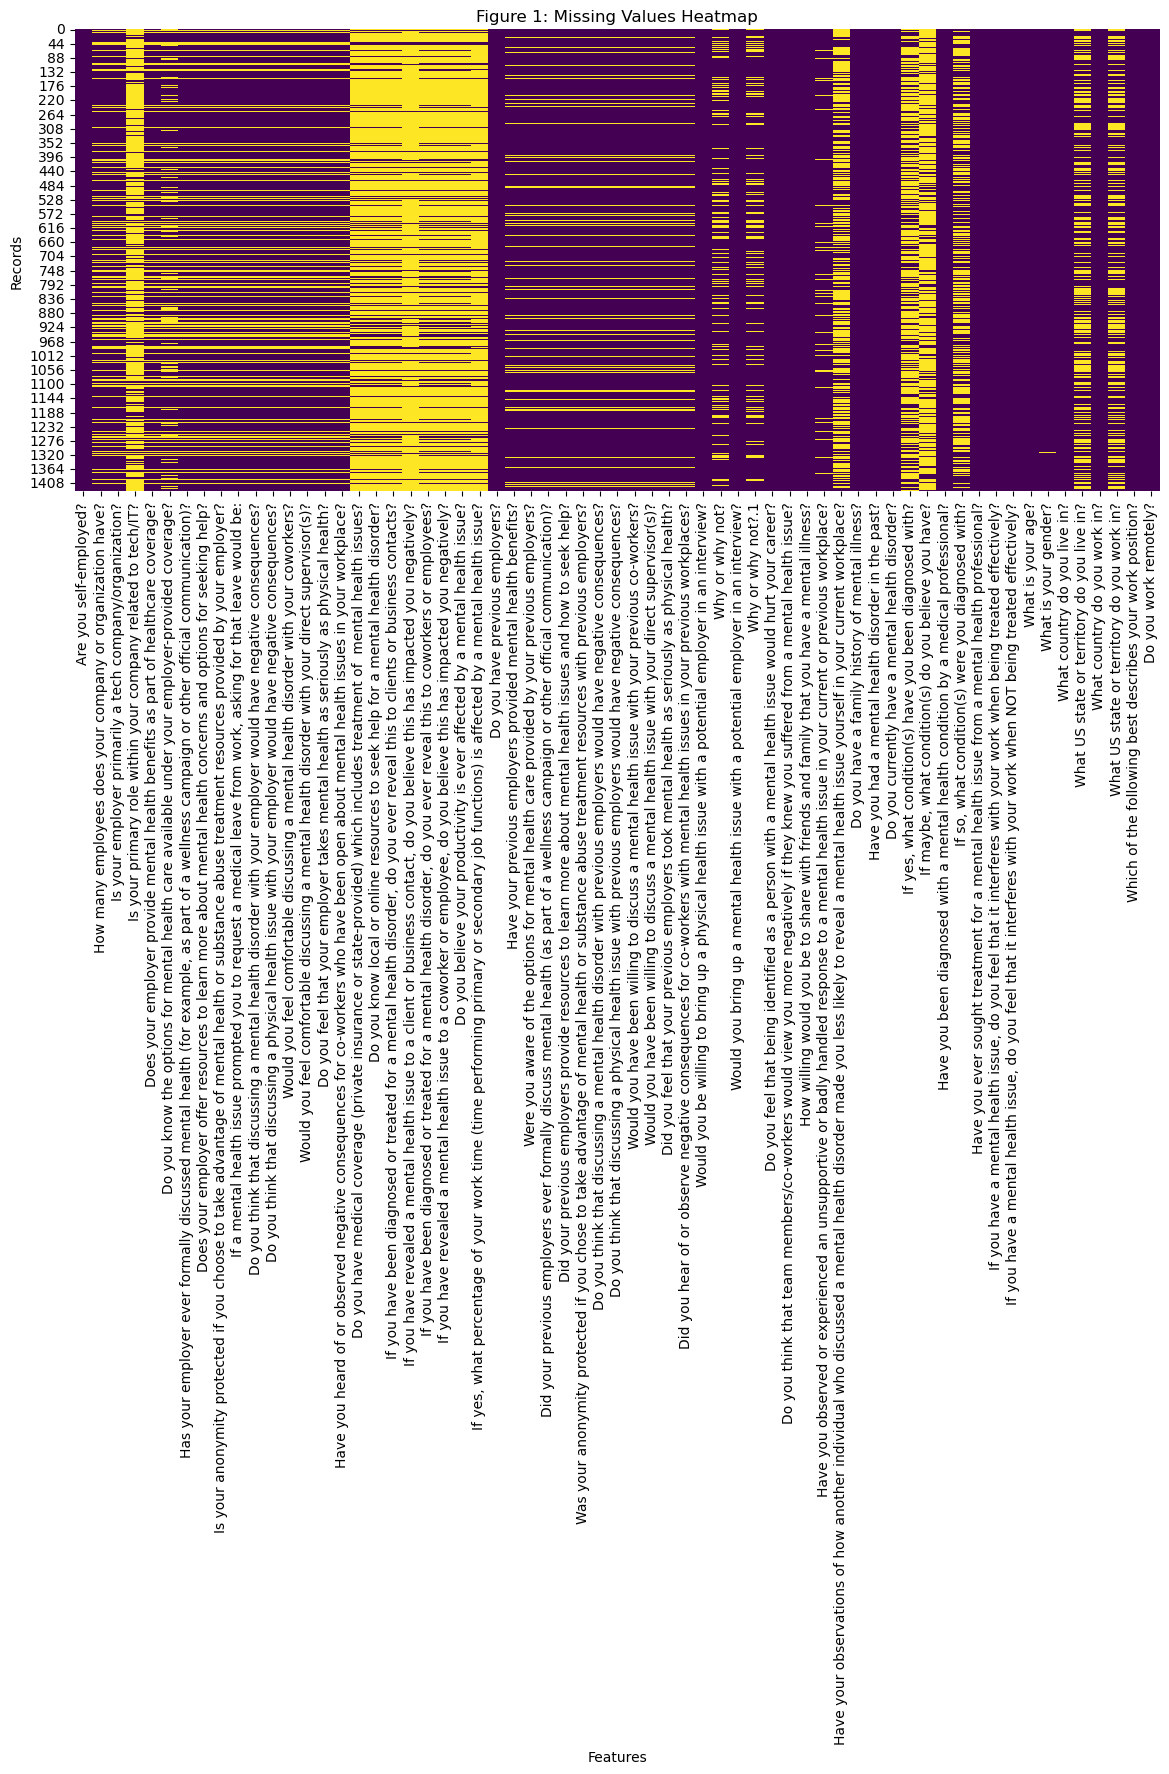

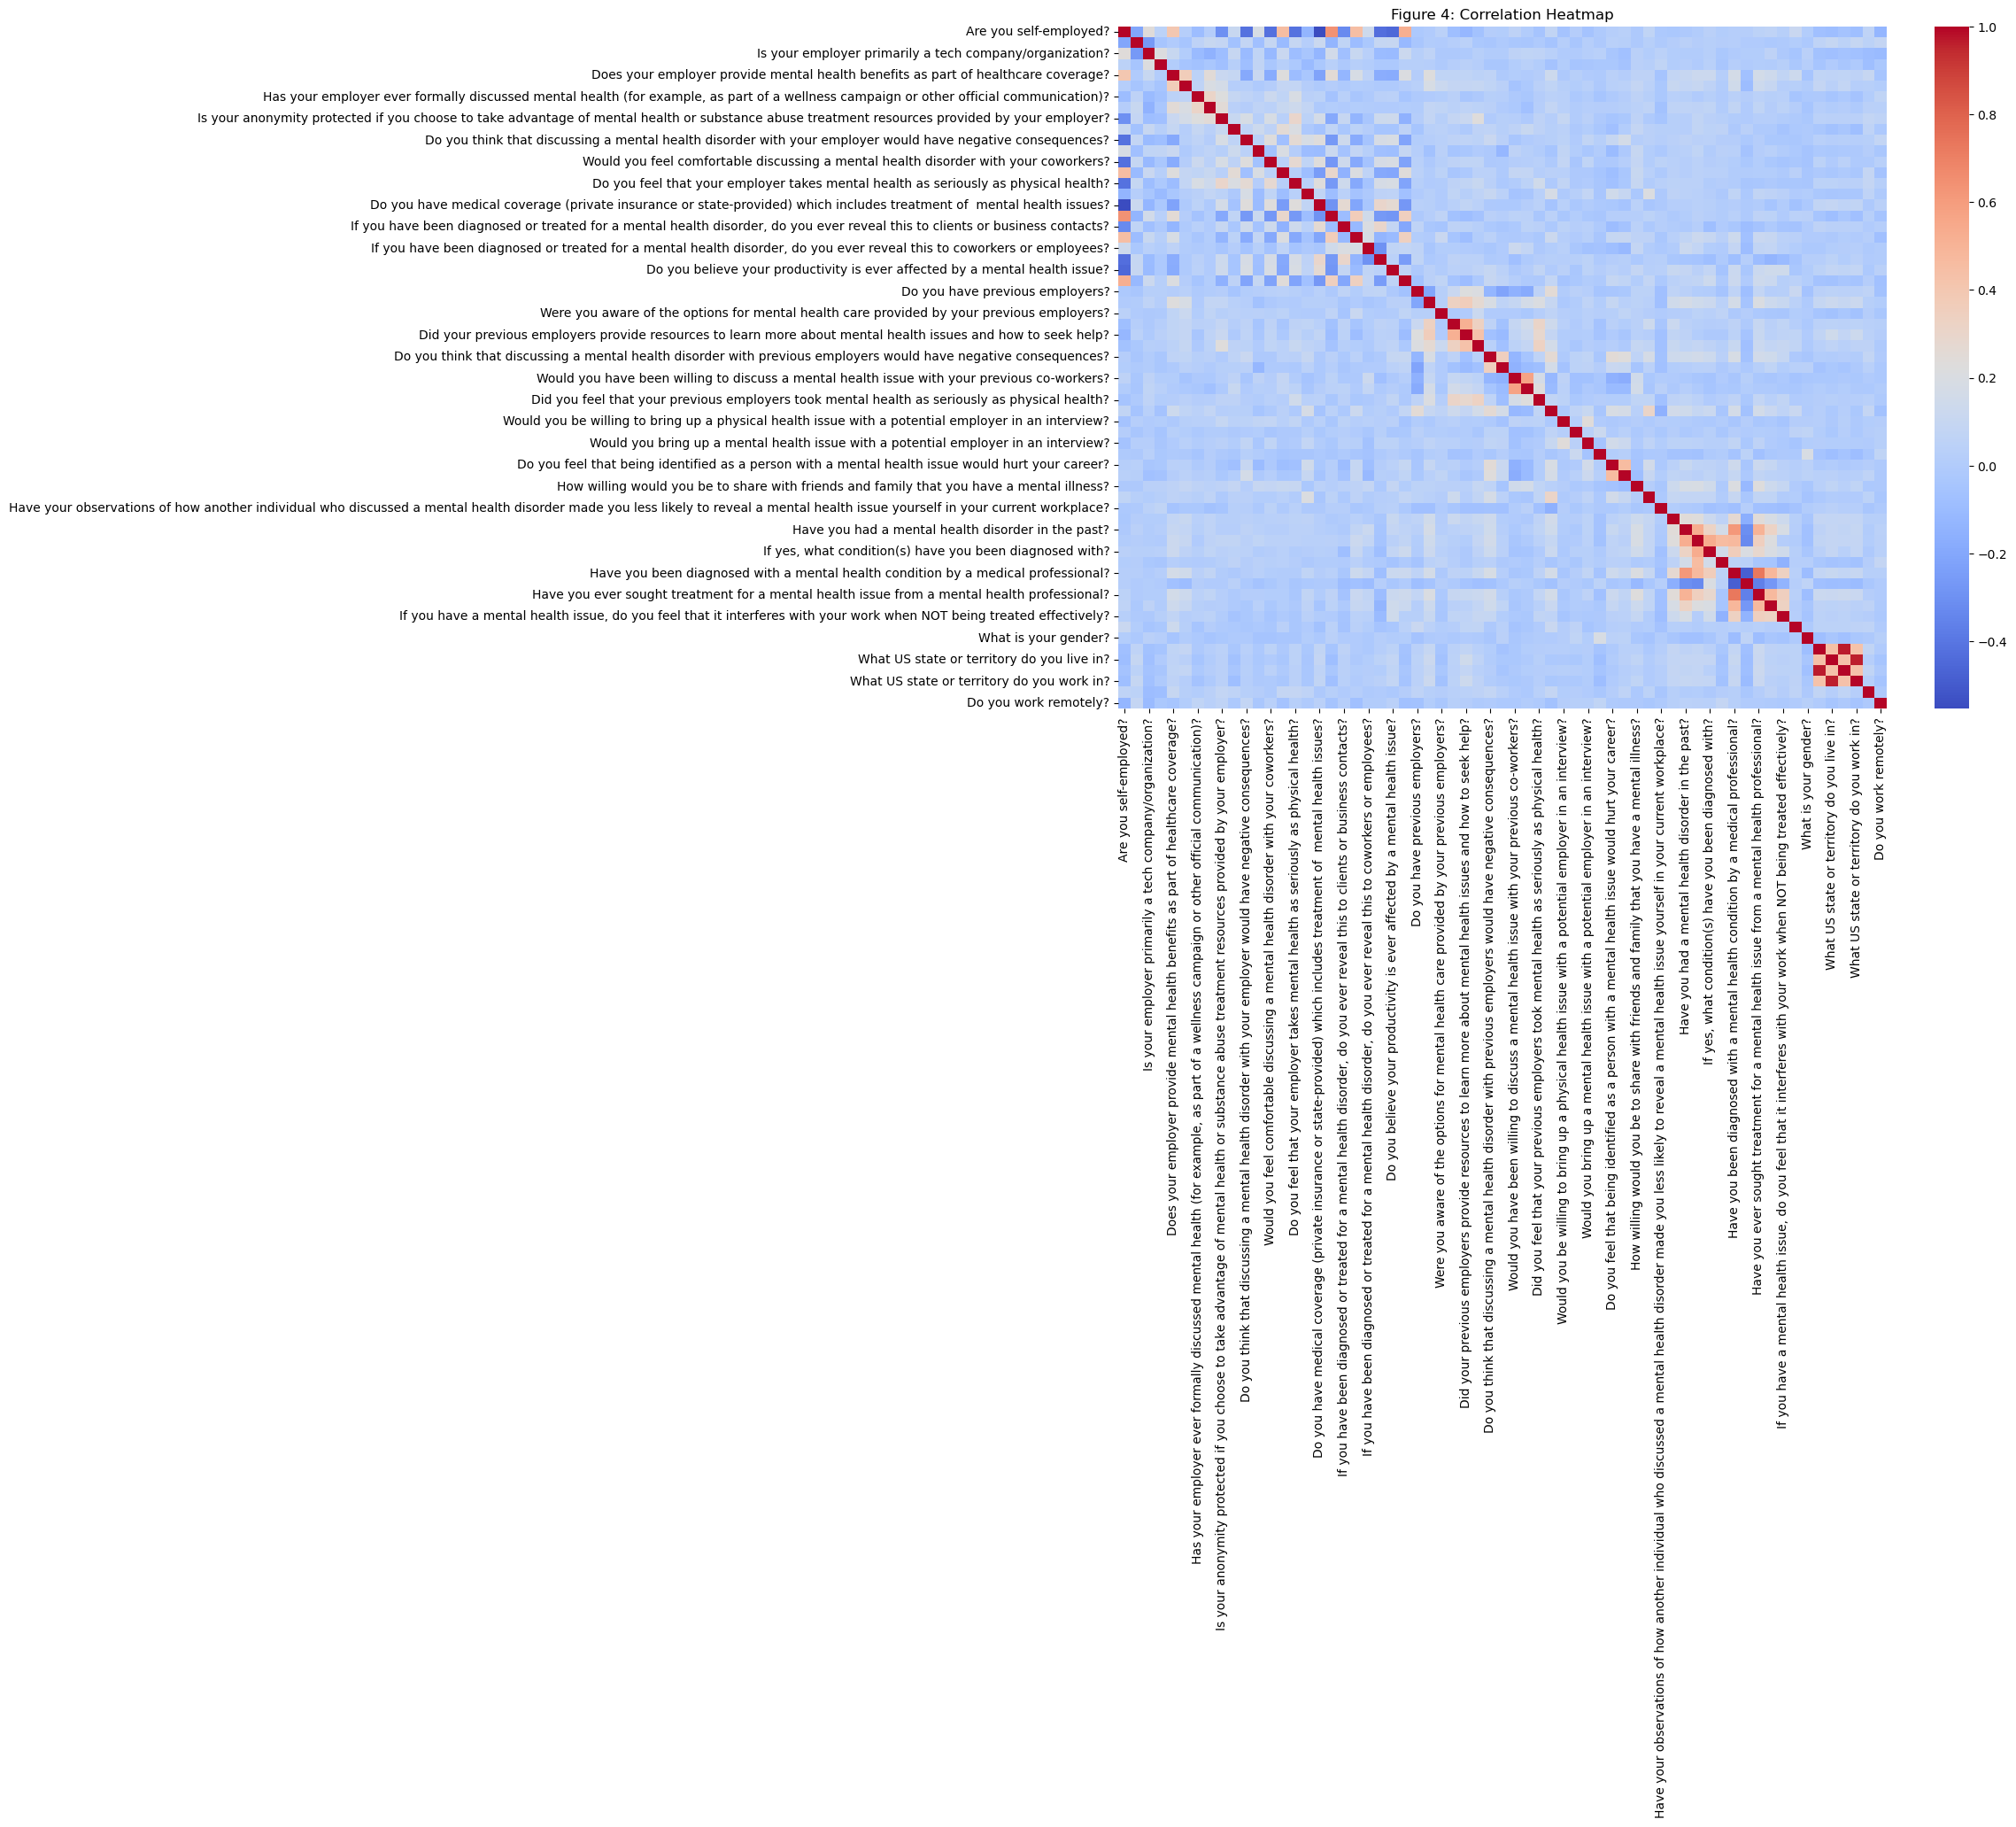

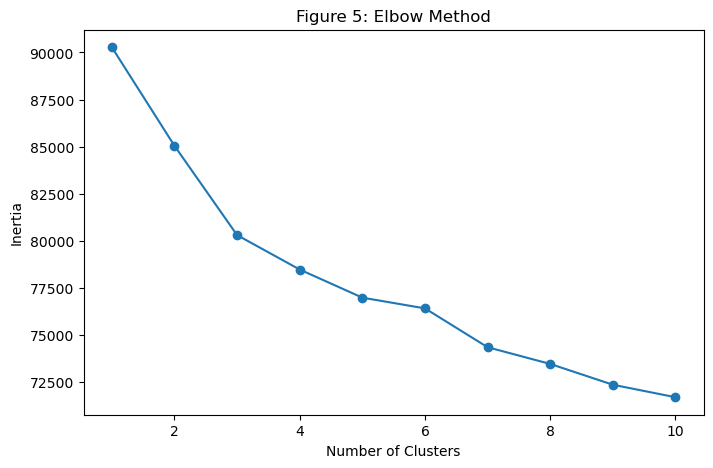

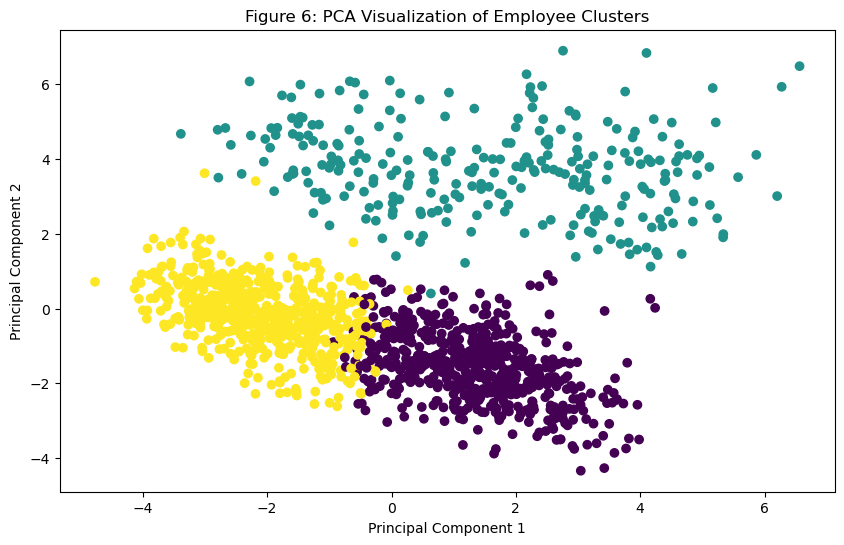

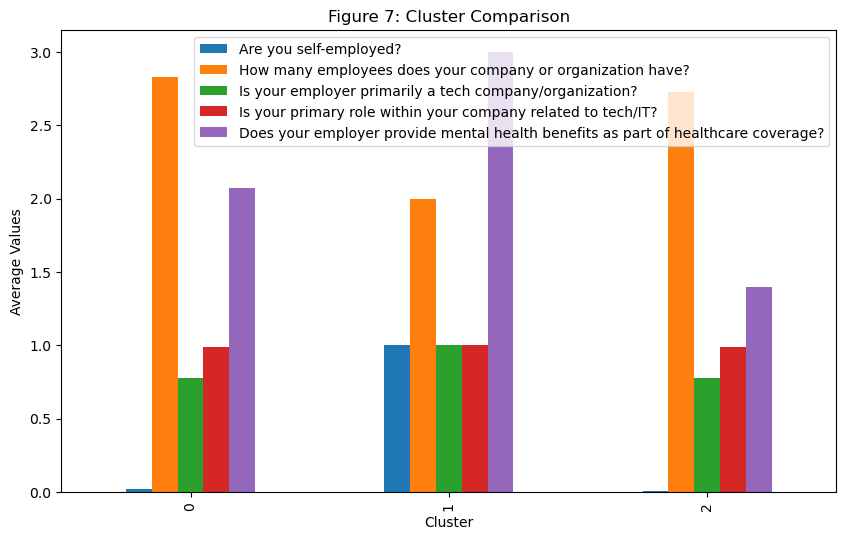


CLUSTER COUNTS
Cluster
0    582
2    578
1    273
Name: count, dtype: int64

CLUSTER MEANS
         Are you self-employed?  \
Cluster                           
0                      0.017182   
1                      1.000000   
2                      0.006920   

         How many employees does your company or organization have?  \
Cluster                                                               
0                                                 2.828179            
1                                                 2.000000            
2                                                 2.723183            

         Is your employer primarily a tech company/organization?  \
Cluster                                                            
0                                                 0.773196         
1                                                 1.000000         
2                                                 0.773356         

         Is your primary role withi

   Are you self-employed?  \
0                       0   
1                       0   
2                       0   
3                       1   
4                       0   

  How many employees does your company or organization have?  \
0                                             26-100           
1                                               6-25           
2                                               6-25           
3                                                NaN           
4                                               6-25           

   Is your employer primarily a tech company/organization?  \
0                                                1.0         
1                                                1.0         
2                                                1.0         
3                                                NaN         
4                                                0.0         

   Is your primary role within your company related to tech/IT?  \


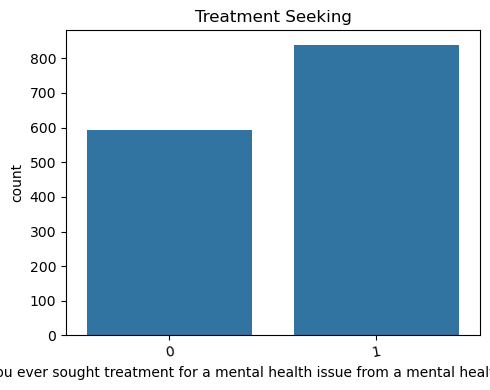

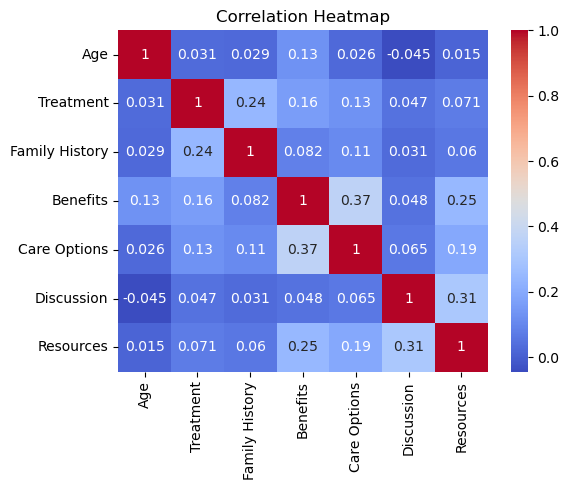

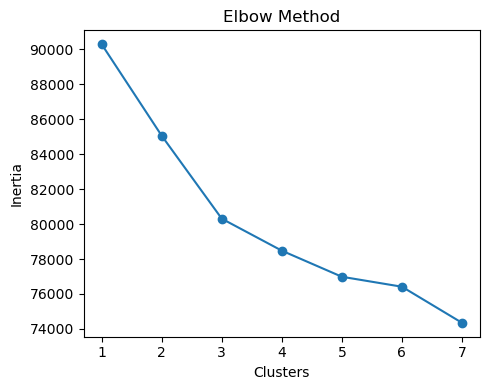

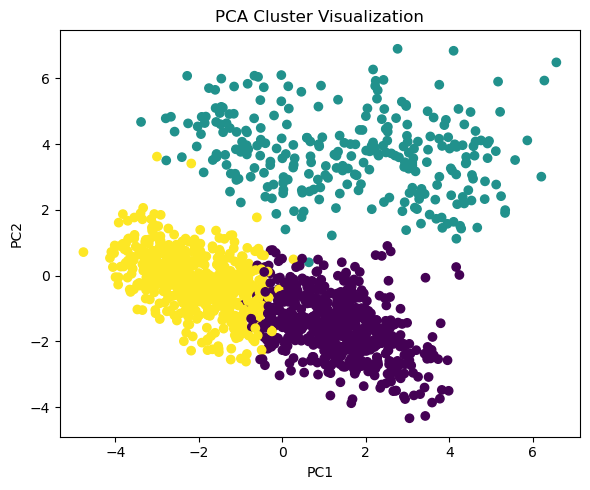


Cluster Counts:
Cluster
0    582
2    578
1    273
Name: count, dtype: int64

Cluster Means:
         Are you self-employed?  \
Cluster                           
0                      0.017182   
1                      1.000000   
2                      0.006920   

         How many employees does your company or organization have?  \
Cluster                                                               
0                                                 2.828179            
1                                                 2.000000            
2                                                 2.723183            

         Is your employer primarily a tech company/organization?  \
Cluster                                                            
0                                                 0.773196         
1                                                 1.000000         
2                                                 0.773356         

         Is your primary role wit

In [9]:
# 1. IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. LOAD DATASET

df = pd.read_csv("mental_health.csv")

# 3. BASIC DATA CHECK


print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)


# 4. HANDLE MISSING VALUES

for col in df.columns:

    if df[col].dtype == 'object':

        df[col].fillna(df[col].mode()[0], inplace=True)

    else:

        df[col].fillna(df[col].median(), inplace=True)


# 5. FIGURE 1 - TREATMENT SEEKING

plt.figure(figsize=(5,4))

sns.countplot(
    x='Have you ever sought treatment for a mental health issue from a mental health professional?',
    data=df
)

plt.title("Treatment Seeking")

plt.xticks(rotation=10)

plt.tight_layout()

plt.show()


# 6. ENCODE CATEGORICAL VARIABLES

df2 = df.copy()

encoder = LabelEncoder()

for col in df2.columns:

    if df2[col].dtype == 'object':

        df2[col] = encoder.fit_transform(df2[col].astype(str))

# 7. FIGURE 2 - SMALL CORRELATION HEATMAP

selected_columns = [

    'What is your age?',

    'Have you ever sought treatment for a mental health issue from a mental health professional?',

    'Do you have a family history of mental illness?',

    'Does your employer provide mental health benefits as part of healthcare coverage?',

    'Do you know the options for mental health care available under your employer-provided coverage?',

    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',

    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?'
]

# Create correlation matrix
corr = df2[selected_columns].corr()

# SHORT LABELS
short_labels = [
    'Age',
    'Treatment',
    'Family History',
    'Benefits',
    'Care Options',
    'Discussion',
    'Resources'
]

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    xticklabels=short_labels,
    yticklabels=short_labels
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# 8. FEATURE SCALING

X = df2.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# 9. FIGURE 3 - ELBOW METHOD


inertia = []

for k in range(1,8):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(5,4))

plt.plot(
    range(1,8),
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.tight_layout()

plt.show()


# 10. K-MEANS CLUSTERING

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df2['Cluster'] = clusters

# 11. PCA DIMENSIONALITY REDUCTION

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)


# 12. FIGURE 4 - PCA CLUSTER VISUALIZATION

plt.figure(figsize=(6,5))

plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=clusters
)

plt.title("PCA Cluster Visualization")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.tight_layout()

plt.show()

# 13. CLUSTER COUNTS
print("\nCluster Counts:")

print(df2['Cluster'].value_counts())

# 14. CLUSTER MEANS


print("\nCluster Means:")

print(df2.groupby('Cluster').mean())


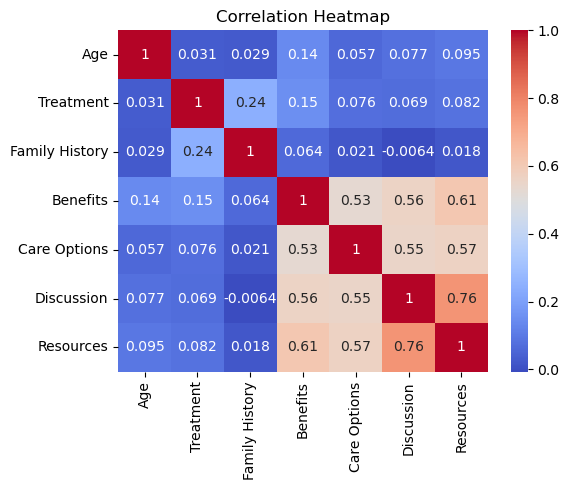

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("mental_health.csv")

# Encode categorical variables
df2 = df.copy()

for col in df2.columns:
    if df2[col].dtype == 'object':
        df2[col] = LabelEncoder().fit_transform(df2[col].astype(str))

# Select important columns
selected_columns = [

    'What is your age?',

    'Have you ever sought treatment for a mental health issue from a mental health professional?',

    'Do you have a family history of mental illness?',

    'Does your employer provide mental health benefits as part of healthcare coverage?',

    'Do you know the options for mental health care available under your employer-provided coverage?',

    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',

    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?'
]

# Create correlation matrix
corr = df2[selected_columns].corr()

# SHORT LABELS
short_labels = [
    'Age',
    'Treatment',
    'Family History',
    'Benefits',
    'Care Options',
    'Discussion',
    'Resources'
]

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    xticklabels=short_labels,
    yticklabels=short_labels
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()